주식의 높은 리스크를 관리할 수 있는 방법 중 하나는 바로 채권혼합입니다.

채권을 혼합하는 이유는 일반적으로 채권은 주식과 가격 움직임이 반대이기 때문입니다.  

▶ 채권 혼합 포트폴리오의 3대 핵심 효용

* ***1)상관계수를 활용한 리스크 헤징***

  주식과 채권이 지닌 '역(-)의 상관관계'를 활용하여 시스템 리스크를 방어합니다. 증시 급락 시 안전자산인 국채 가격이 상승하며 포트폴리오 전체의 변동성을 상쇄하는 상호 보완적 방어 기제를 구축합니다.

* ***2)하방 경직성 확보 및 손실 비대칭성 극복***

  최대 낙폭(MDD)을 통계적으로 유의미한 수준까지 낮춰 자본을 보전합니다. 손실률이 커질수록 회복에 필요한 수익률이 기하급수적으로 늘어나는 '손실의 비대칭성'을 사전에 차단하여 장기 복리 효과를 유지합니다.

* ***3)위험 조정 수익률의 극대화***

  단순 기대 수익률이 아닌, 변동성 대비 성과 지표인 샤프 지수를 개선합니다. 동일한 위험 수준에서 기대할 수 있는 최상의 수익률 곡선인 '효율적 투자선'에 근접한 포트폴리오를 운용할 수 있습니다.


In [3]:
pip install -U finance-datareader

#### 함수

In [4]:
import FinanceDataReader as fdr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def get_close(ticker, start, end=None):
    """
    종가 데이터 수집 (Get Close Prices)
    """
    return fdr.DataReader(ticker, start, end)['Close']

def calc_daily_return(prices):
    """
    일별 수익률 계산 (Calculate Daily Returns)
    """
    return prices.pct_change().fillna(0)

def calc_cum_return(prices):
    """
    누적 수익률(자산 흐름) 계산 (Calculate Cumulative Returns)
    """
    return prices / prices.iloc[0]

def calc_portfolio(prices, weight=None):
    """
    포트폴리오 수익률 계산 (Calculate Portfolio Returns)
    returns: (일별 수익률, 누적 수익률)
    """
    # 1. 누적 수익률 계산
    cum_ret = calc_cum_return(prices)

    # 2. 비중 설정 (기본값: 동일 비중)
    if not weight:
        weight = [1/len(prices.columns)] * len(prices.columns)

    # 3. 포트폴리오 누적 수익률 (가중 평균)
    # 각 자산의 누적 수익률에 비중을 곱해 합산합니다. (Buy & Hold 가정)
    port_cum_ret = (cum_ret * weight).sum(axis=1)

    # 4. 포트폴리오 일별 수익률 (역산)
    port_daily_ret = port_cum_ret.pct_change().fillna(0)

    return port_daily_ret, port_cum_ret


def evaluate_performance(cum_ret, daily_ret, risk_free_rate=0.02):
    """
    성과 지표 평가 (CAGR, MDD, Volatility, Sharpe ratio)
    """

    # 1. 수익성 (CAGR)
    total_ret = cum_ret.iloc[-1]
    years = len(cum_ret) / 252
    cagr = total_ret ** (1 / years) - 1

    # 2. 안정성 (MDD)
    historical_max = cum_ret.cummax()
    dd = (cum_ret - historical_max) / historical_max * 100
    mdd = dd.min()

    # 3. 위험 (변동성)
    daily_vol = daily_ret.std()               # 일일 변동성
    annual_vol = daily_vol * np.sqrt(252)     # 연간 변동성

    # 4. 효율 (Sharpe Ratio)
    annual_return = daily_ret.mean() * 252    # 연간 수익률 (산술 평균)
    sharpe_ratio = (annual_return - risk_free_rate) / annual_vol # 위험 한 단위당 수익

    print(f"▶ 최종 수익률   : {(cum_ret.iloc[-1]-1)*100:.2f}%")
    print(f"=== 성과 평가 리포트 ===")
    print(f"1. 수익성 (CAGR) : {cagr*100:.2f}%")
    print(f"2. 안정성 (MDD)  : {mdd:.2f}%")
    print(f"-" * 30)
    print(f"3. 연간 변동성   : {annual_vol*100:.2f}%")
    print(f"4. 샤프 지수     : {sharpe_ratio:.4f}")

    return cagr, dd, mdd

# 채권 혼합

In [5]:
# 코스피 ETF 채권 ETF 1:1 혼합

# 데이터 로드
kodex200 = get_close("069500", "2000") # 코스피200 ETF
kodex10Bond = get_close("152380", "2000") # kodex 국고채 10년물 ETF

# kodex200 = 069500
# kodex10Bond = 152380
# S&P500 = SPY
# 미국 7-10 국채 = IEF

Data = pd.concat([kodex200, kodex10Bond], axis=1)
Data.columns = ['kodex200', 'kodex10Bond']
Data.dropna(inplace=True)
Data

,kodex200,kodex10Bond
Date,,
2013-10-22,21504,54140
2013-10-23,21265,54605
2013-10-24,21332,54446
2013-10-25,21174,54496
2013-10-28,21356,54397
...,...,...
2026-01-05,65040,67560
2026-01-06,66210,67560
2026-01-07,66720,67850


In [7]:
fdr.DataReader('152380', '2000-01-01')

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2013-10-22,54056,54184,54016,54140,47,NaN
2013-10-23,54407,54605,54407,54605,327,0.008589
2013-10-24,54565,54639,54446,54446,24,-0.002912
2013-10-25,54446,54501,54446,54496,190,0.000918
2013-10-28,54412,54412,54397,54397,111,-0.001817
...,...,...,...,...,...,...
2026-01-05,67625,67625,67310,67560,9067,-0.002363
2026-01-06,67565,67880,67530,67560,4803,0.000000
2026-01-07,67705,67855,67660,67850,3139,0.004292


In [8]:
# 결측치 가볍게 검사
pd.isnull(Data).sum()

,0
kodex200,0
kodex10Bond,0


**주식과 채권의 움직임 비교**

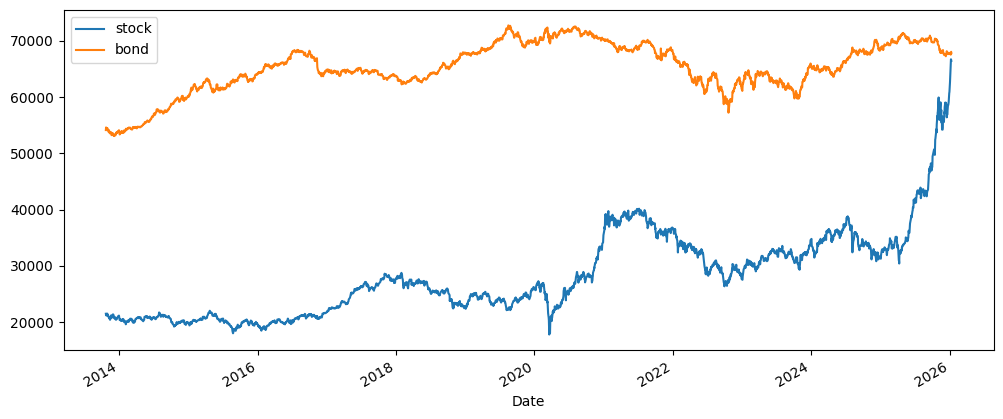

In [9]:
plt.figure(figsize=(12, 5))
Data['kodex200'].plot(label="stock")
Data['kodex10Bond'].plot(label="bond")
plt.legend()
plt.show()

#데이터 정규화

가격 수준이 다르기 때문에 비교가 쉽지 않습니다.  
쉽게 "체급이 다른 선수들을 동일한 링 위에 올리는 과정" 이라고 생각하시면 됩니다.

삼성전자(7만 원)와 비트코인(1억 원)을 단순히 가격으로만 비교하면 그래프의 왜곡이 심해집니다. 이때 필요한 것이 바로 '데이터 표준화'입니다. 각 데이터가 '평균으로부터 얼마나 떨어져 있는지(표준편차)'를 기준으로 변환하면, 가격표 떼고 오직 '움직임의 강도'만으로 공정한 비교가 가능해집니다. 이를 통해 모든 자산의 움직임을 평균 0, 표준편차 1인 정규분포 형태로 통일할 수 있습니다.

정규화 = $ \frac{주가 - 주가 평균}{주가 표준편차} $

In [10]:
# 데이터 정규화
normalizedData = (Data - Data.mean()) / Data.std()

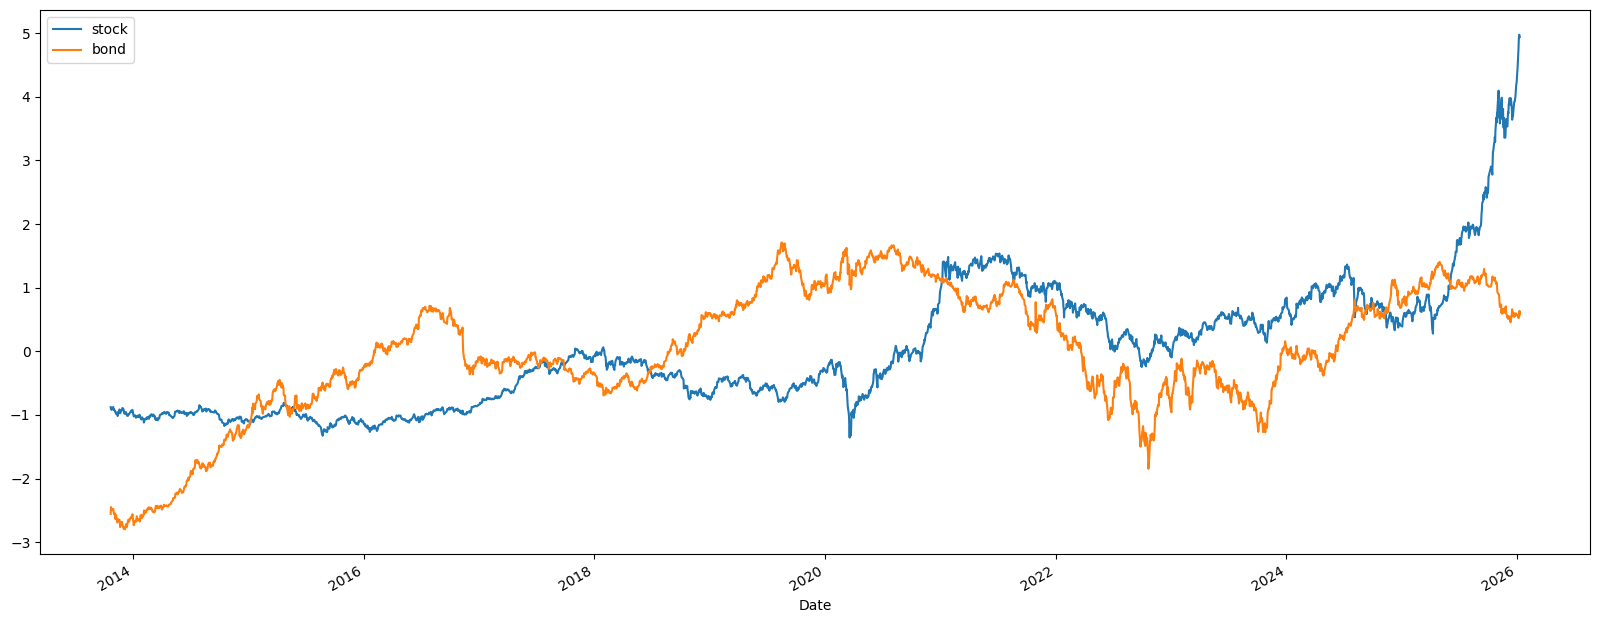

In [11]:
# 정규화 가격 시각화
plt.figure(figsize=(20, 8))
normalizedData['kodex200'].plot(label="stock")
normalizedData['kodex10Bond'].plot(label="bond")
plt.legend()
plt.show()

## 주식 ETF 성과

우선 KODEX200은 코스피 200에 랭크된 종목에 골고루 분산투자하는 ETF입니다.  
이로 인해 분산투자를 했다고 가정하고,
주식 분산 투자 성과를 계산해보겠습니다.

In [13]:
kodex200_day_return = calc_daily_return(Data['kodex200'])
kodex200_cum_return = calc_cum_return(Data['kodex200'])

kodex200cagr, kodex200dd, kodex200mdd = evaluate_performance(kodex200_cum_return, kodex200_day_return)

▶ 최종 수익률   : 208.97%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 9.94%
2. 안정성 (MDD)  : -38.09%
------------------------------
3. 연간 변동성   : 17.37%
4. 샤프 지수     : 0.5174


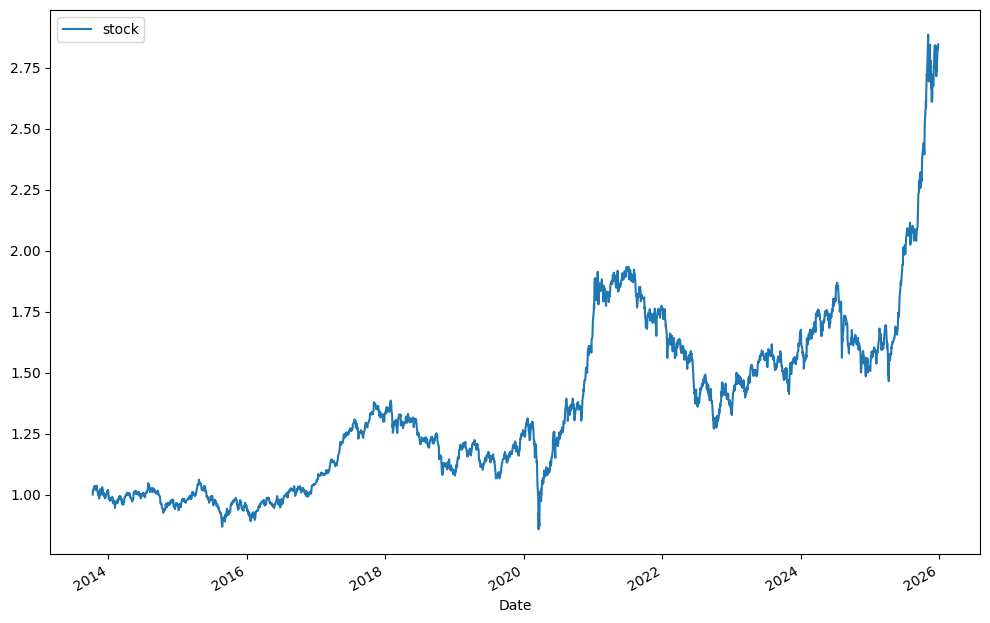

In [ ]:
plt.figure(figsize=(12, 8))
kodex200_cum_return.plot(label="stock")
plt.legend()
plt.show()

In [ ]:
# _ = analyze_portfolio(['069500'],[1], '2000')

# 포트폴리오 비교

## port1: 주식,채권(10년물) 1:1 혼합

In [16]:
# 코스피 ETF 채권 ETF 1:1 혼합

# 데이터 로드
kodex200 = get_close("069500", "2000") # 코스피200 ETF
kodex10Bond = get_close("152380", "2000") # kodex 국고채 10년물 ETF

Data = pd.concat([kodex200, kodex10Bond], axis=1)
Data.columns = ['kodex200', 'kodex10Bond']
Data.dropna(inplace=True)
Data
port_day_return, port_cum_return = calc_portfolio(Data)

In [17]:
port_cum_return

,0
Date,
2013-10-22,1.000000
2013-10-23,0.998737
2013-10-24,0.998827
2013-10-25,0.995615
2013-10-28,0.998932
...,...
2026-01-05,2.136215
2026-01-06,2.163419
2026-01-07,2.177955


In [19]:
# 투자 성과
portcagr, portdd, portmdd = evaluate_performance(port_cum_return, port_day_return)

▶ 최종 수익률   : 116.55%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 6.71%
2. 안정성 (MDD)  : -26.51%
------------------------------
3. 연간 변동성   : 9.49%
4. 샤프 지수     : 0.5206


**시각화**

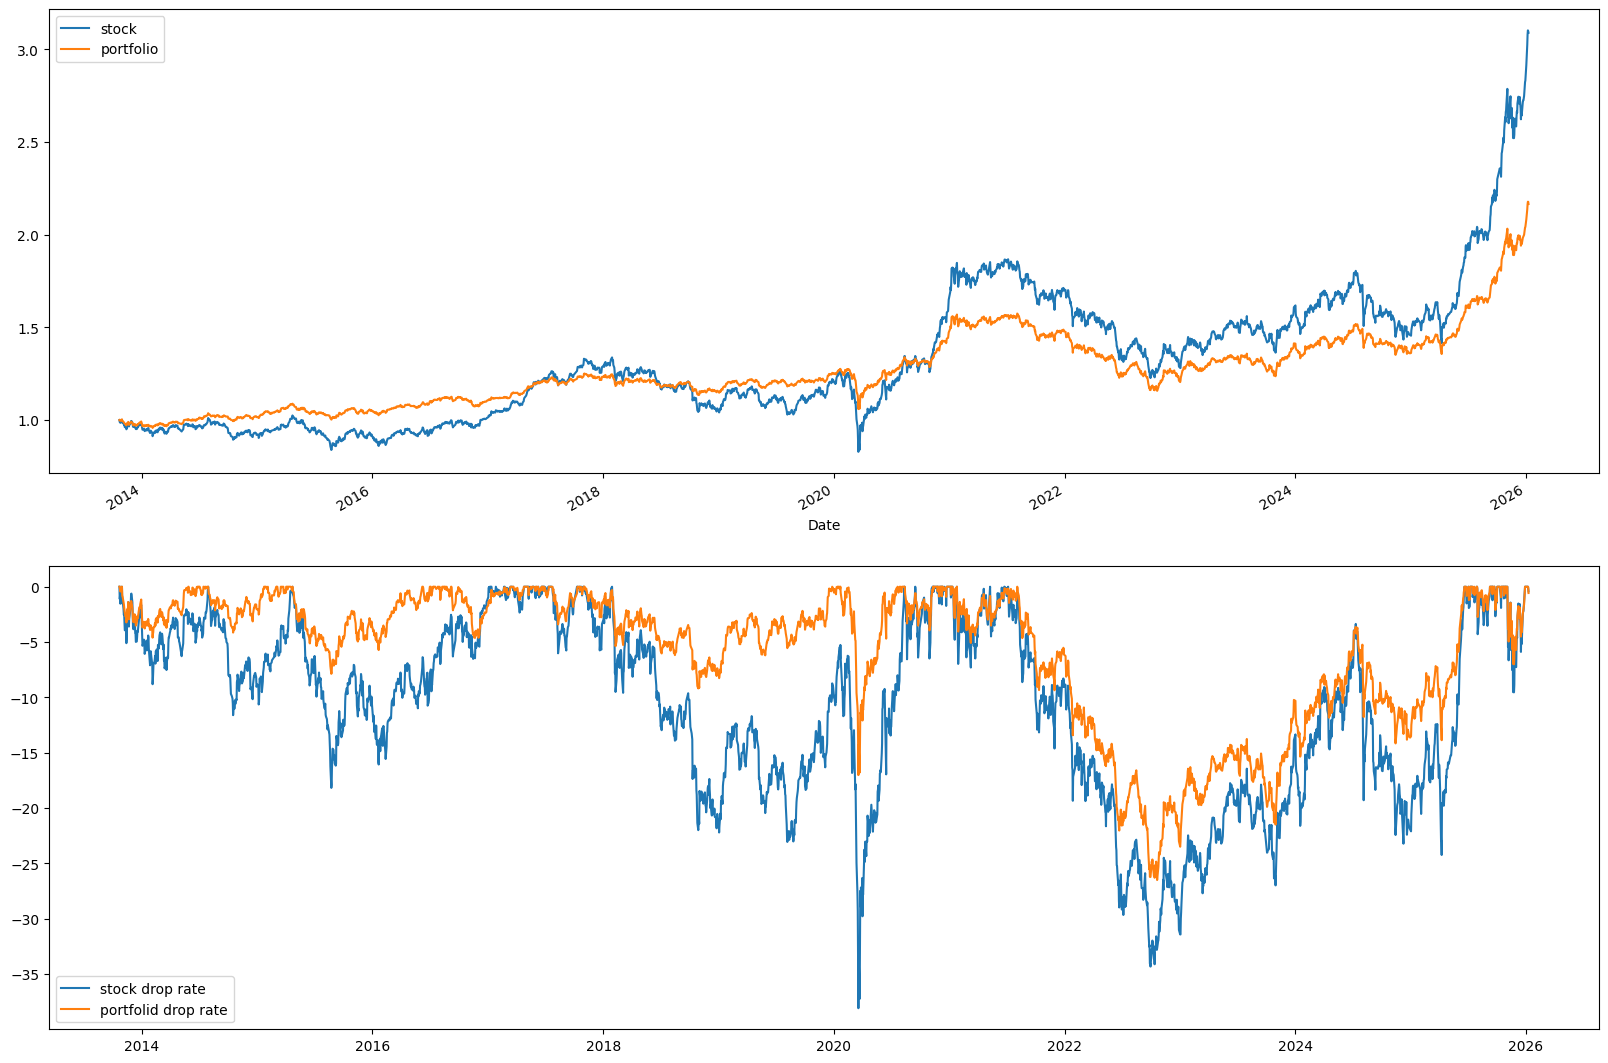

In [20]:
plt.figure(figsize=(20, 15))

# 수익곡선
plt.subplot(2,1,1)
kodex200_cum_return.plot(label="stock")
port_cum_return.plot(label="portfolio")
plt.legend()

# dd 곡선
plt.subplot(2,1,2)
plt.plot(kodex200dd , label="stock drop rate")
plt.plot(portdd , label="portfolid drop rate")
plt.legend()

plt.show()

In [ ]:
# kodex200 = "069500" # 코스피200 ETF
# kodex10Bond = "152380" # kodex 국고채 10년물 ETF

# _ = analyze_portfolio(['069500','152380'],[0.5,0.5], '2000')

코스피200 ETF에만 투자했을 땐 MDD가 38%에 달했지만  
채권 ETF를 혼합했을 땐 MDD가 26.6%로 약 12% 이상 감소한 것을 확인할 수 있습니다.  

## port2: 주식,현금 1:1 혼합

In [21]:
# 주식(50), 현금(50) 혼합
Data2 = pd.DataFrame(kodex200)
Data2.columns = ['kodex200']
Data2.loc[:, 'cash'] = 1

Data2 = Data2.loc['2013':]
Data2

,kodex200,cash
Date,,
2013-10-22,21504,1
2013-10-23,21265,1
2013-10-24,21332,1
2013-10-25,21174,1
2013-10-28,21356,1
...,...,...
2026-01-05,65040,1
2026-01-06,66210,1
2026-01-07,66720,1


In [23]:
# 주식 현금 포트폴리오 성과
port_day_return2, port_cum_return2 = calc_portfolio(Data2)
print("주식:현금 1:1 혼합 포트폴리오 최종수익률")
print(port_cum_return2.iloc[-1])
portcagr2, portdd2, portmdd2 = evaluate_performance(port_cum_return2,port_day_return2 )

주식:현금 1:1 혼합 포트폴리오 최종수익률
2.039364769345238
▶ 최종 수익률   : 103.94%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 6.17%
2. 안정성 (MDD)  : -22.36%
------------------------------
3. 연간 변동성   : 9.98%
4. 샤프 지수     : 0.4495


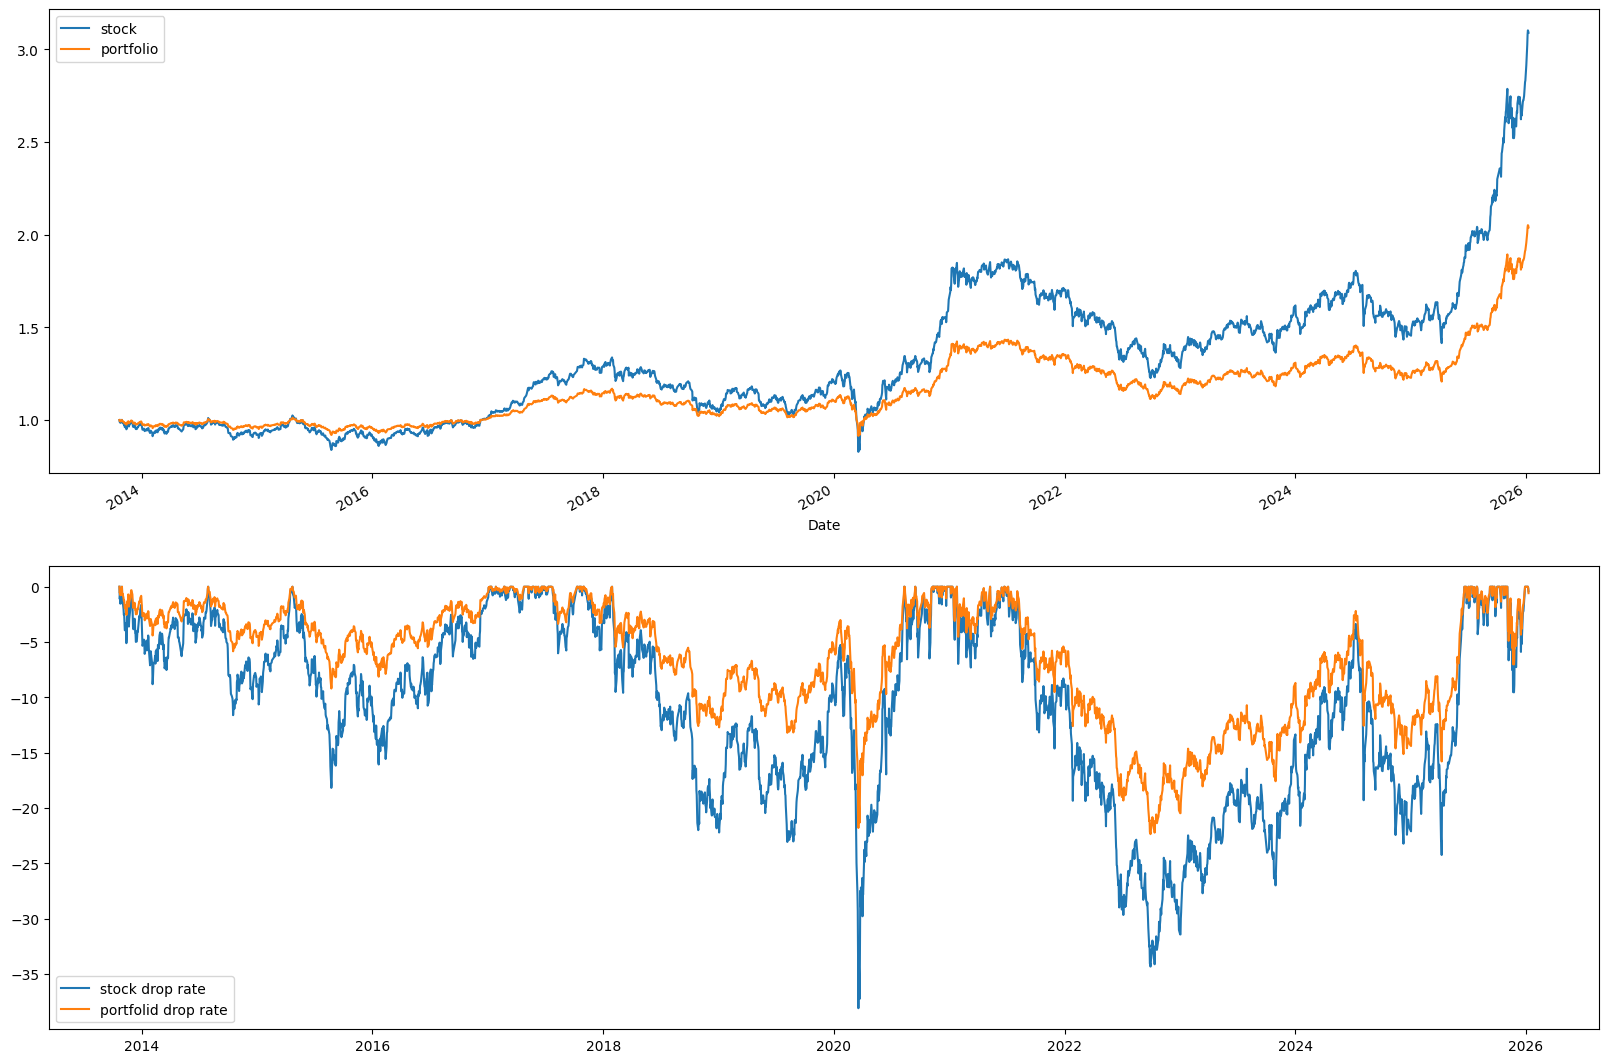

In [24]:
plt.figure(figsize=(20, 15))

# 수익곡선
plt.subplot(2,1,1)
kodex200_cum_return.plot(label="stock")
port_cum_return2.plot(label="portfolio")
plt.legend()

# dd 곡선
plt.subplot(2,1,2)
plt.plot(kodex200dd , label="stock drop rate")
plt.plot(portdd2 , label="portfolid drop rate")
plt.legend()

plt.show()

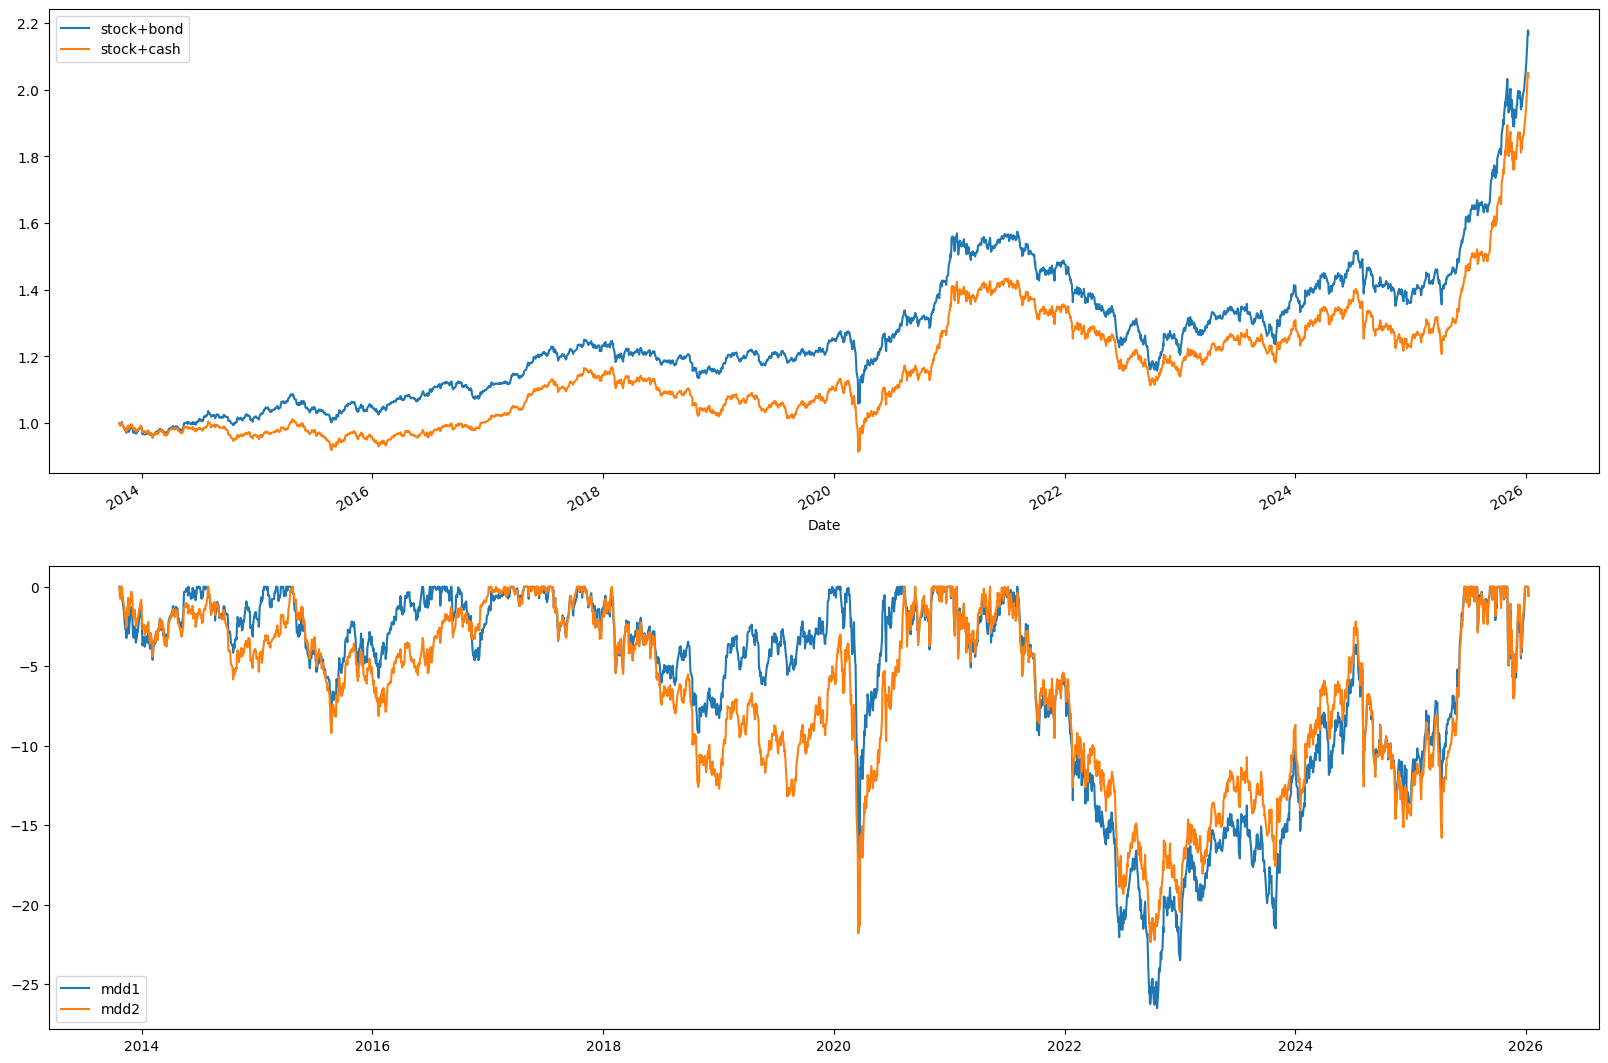

In [25]:
plt.figure(figsize=(20, 15))

# 수익곡선
plt.subplot(2,1,1)
port_cum_return.plot(label="stock+bond")
port_cum_return2.plot(label="stock+cash")
plt.legend()

# dd 곡선
plt.subplot(2,1,2)
plt.plot(portdd , label="mdd1")
plt.plot(portdd2 , label="mdd2")
plt.legend()

plt.show()

## port3: 주식,단기채권 1:1 혼합

In [26]:
#주식(50), 단기채권(50) 혼합
kodexShortBond = get_close("153130", "2013")
Data3 = pd.DataFrame(kodex200)
Data3.columns = ['kodex200']
Data3 = pd.concat([Data3, kodexShortBond], axis=1)
Data3.dropna(inplace=True)
Data3

,kodex200,Close
Date,,
2013-10-22,21504,90511
2013-10-23,21265,90524
2013-10-24,21332,90541
2013-10-25,21174,90541
2013-10-28,21356,90545
...,...,...
2026-01-05,65040,113510
2026-01-06,66210,113525
2026-01-07,66720,113525


In [27]:
port_day_return3, port_cum_return3 = calc_portfolio(Data3)
portcagr3, portdd3, portmdd3 = evaluate_performance(port_cum_return3, port_day_return3)

▶ 최종 수익률   : 116.67%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 6.71%
2. 안정성 (MDD)  : -21.09%
------------------------------
3. 연간 변동성   : 9.44%
4. 샤프 지수     : 0.5235


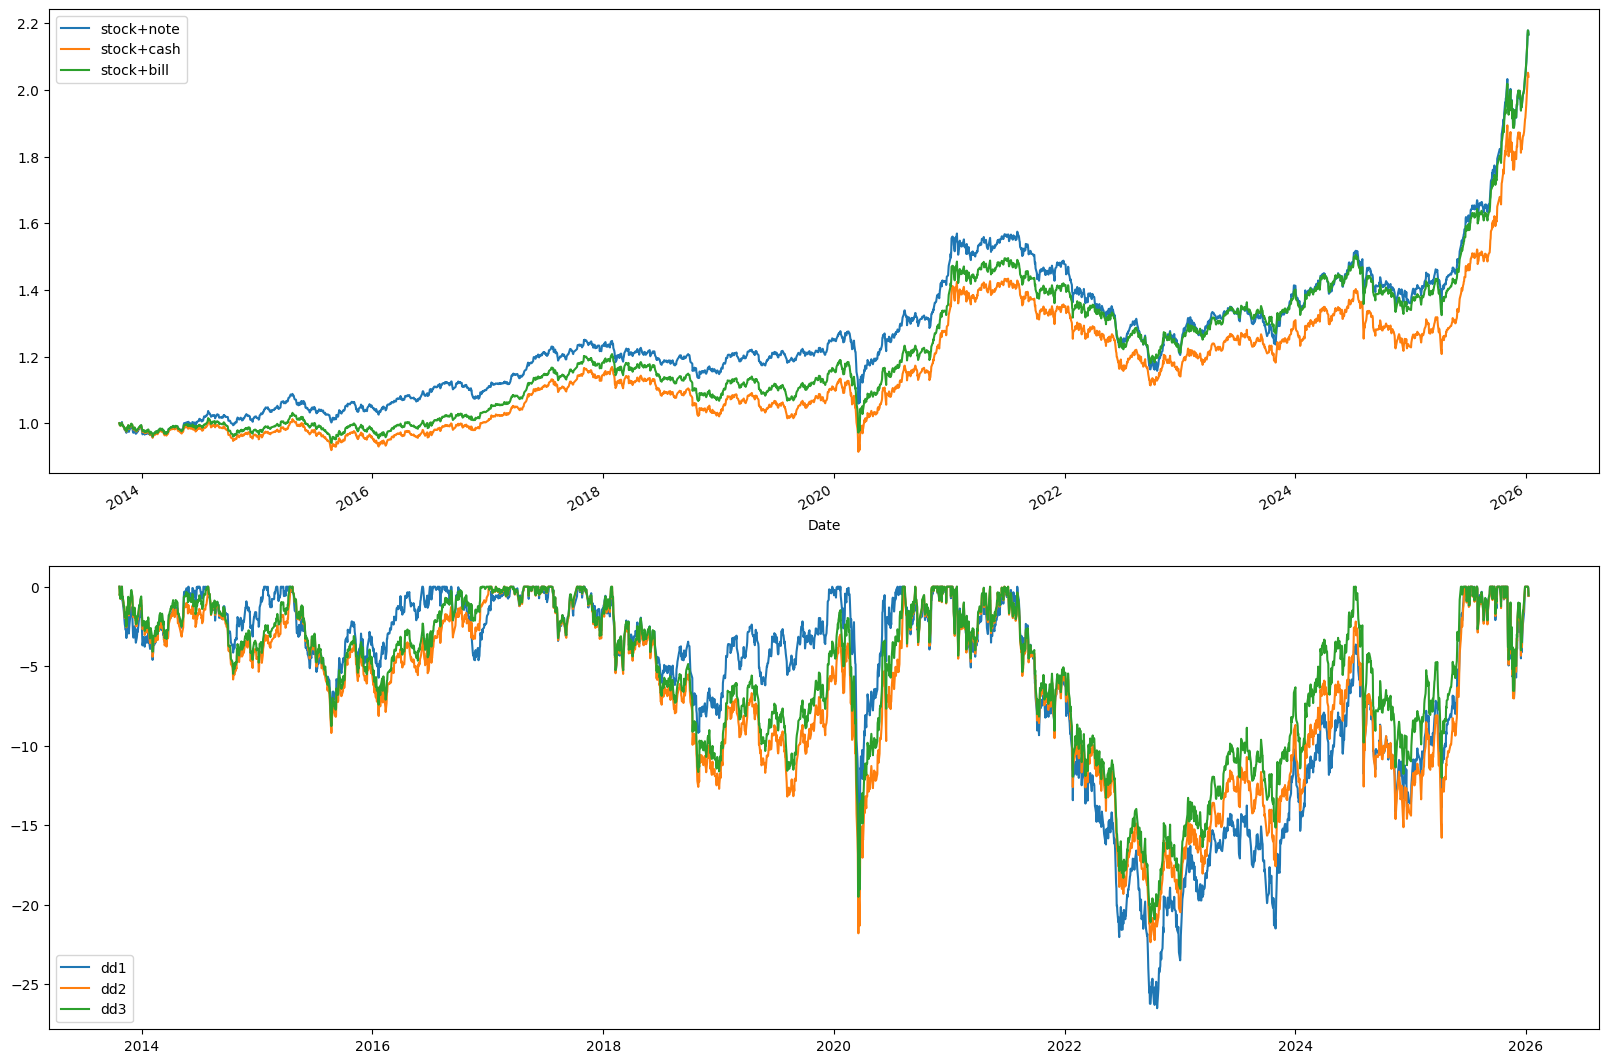

In [28]:
plt.figure(figsize=(20, 15))

# 수익곡선
plt.subplot(2,1,1)
port_cum_return.plot(label="stock+note")
port_cum_return2.plot(label="stock+cash")
port_cum_return3.plot(label="stock+bill")
plt.legend()

# dd 곡선
plt.subplot(2,1,2)
plt.plot(portdd , label="dd1")
plt.plot(portdd2 , label="dd2")
plt.plot(portdd3 , label="dd3")
plt.legend()

plt.show()